# NYISO Solar Forecasting: Hyperparameter Tuning for System-Level Residual Correction

## Purpose

## Research Context

## Questions to Consider

## Imports and Configuration

In [17]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.model_selection import ParameterGrid
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

from lightgbm import LGBMRegressor, early_stopping as lgb_early_stopping
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

warnings.filterwarnings("ignore")
random_state = 42

plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

## Load Dataset

In [18]:
# repo_root = Path.home() / "Documents" / "Coding" / "ML_NYISOSolarForecast"
repo_root = Path(r"C:\Users\sumai\Documents\ML_NYISOSolarForecasting")

data_root = repo_root / "data"
processed_dir = data_root / "processed"

model_ready_in = processed_dir / "04_system_model_ready_data.csv"

split_date = pd.Timestamp("2024-07-01 00:00:00+00:00")
validation_start = pd.Timestamp("2024-01-01 00:00:00+00:00")

In [19]:
df_model = pd.read_csv(model_ready_in, low_memory=False)

df_model.columns = (
    df_model.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

df_model["time_stamp"] = pd.to_datetime(df_model["time_stamp"], utc=True, errors="coerce")
df_model["time_local"] = df_model["time_stamp"].dt.tz_convert("America/New_York")

## Main Features and Time Context

In [20]:
target = "forecast_error_mw"

required_cols = [
    "time_stamp",
    "time_local",
    "zone_name",
    "dataset_split",
    "actual_mw",
    "forecast_mw",
    "forecast_error_mw",
]

missing_required = [c for c in required_cols if c not in df_model.columns]
if missing_required:
    raise ValueError(f"Missing Necessary Columns in Dataset: {missing_required}")

df_model["hour_local"] = df_model["time_local"].dt.hour
df_model["month_local"] = df_model["time_local"].dt.month
df_model["dayofyear_local"] = df_model["time_local"].dt.dayofyear
df_model["is_daylight"] = (df_model["shortwave_radiation"] > 0).astype(int)

feature_cols = [c for c in df_model.columns if c not in required_cols + [
    "hour_local",
    "month_local",
    "dayofyear_local",
    "is_daylight",
]]

if "forecast_mw" not in feature_cols:
    feature_cols = ["forecast_mw"] + feature_cols

print("\nTarget:", target)
print("Number of Features:", len(feature_cols))
print("Feature Columns:")
print(". . .")
print(feature_cols)


Target: forecast_error_mw
Number of Features: 24
Feature Columns:
. . .
['forecast_mw', 'temperature_2m', 'surface_pressure', 'cloud_cover', 'windspeed_10m', 'shortwave_radiation', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dayofyear_sin', 'forecast_x_hour_sin', 'forecast_x_hour_cos', 'shortwave_x_cloud', 'shortwave_x_temp', 'forecast_roll_mean_3', 'shortwave_roll_mean_3', 'forecast_roll_mean_24', 'shortwave_roll_mean_24', 'forecast_diff_1', 'shortwave_diff_1', 'shortwave_ramp_abs', 'is_morning_ramp', 'is_midday']


## Train, Validation, and Test Splits

In [21]:
train_end = df_model.loc[df_model["dataset_split"].eq("train"), "time_stamp"].max()
test_start = df_model.loc[df_model["dataset_split"].eq("test"), "time_stamp"].min()

X = df_model[feature_cols].copy()
y = df_model[target].copy()

train_mask = (
    df_model["dataset_split"].eq("train")
    & y.notna()
)

test_mask = (
    df_model["dataset_split"].eq("test")
    & df_model[target].notna()
    & df_model["actual_mw"].notna()
    & df_model["forecast_mw"].notna()
)

subtrain_mask = (
    df_model["dataset_split"].eq("train")
    & df_model["time_stamp"].lt(validation_start)
    & df_model[target].notna()
)

valid_mask = (
    df_model["dataset_split"].eq("train")
    & df_model["time_stamp"].ge(validation_start)
    & df_model[target].notna()
    & df_model["actual_mw"].notna()
    & df_model["forecast_mw"].notna()
)

train_df = df_model.loc[train_mask].copy()
test_df = df_model.loc[test_mask].copy()
subtrain_df = df_model.loc[subtrain_mask].copy()
valid_df = df_model.loc[valid_mask].copy()

X_train = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()
X_subtrain = subtrain_df[feature_cols].copy()
X_valid = valid_df[feature_cols].copy()

y_train = train_df[target].copy()
y_test = test_df[target].copy()
y_subtrain = subtrain_df[target].copy()
y_valid = valid_df[target].copy()

baseline_actual_test = test_df["actual_mw"].copy()
baseline_forecast_test = test_df["forecast_mw"].copy()

baseline_actual_valid = valid_df["actual_mw"].copy()
baseline_forecast_valid = valid_df["forecast_mw"].copy()

daylight_test_mask = test_df["is_daylight"] == 1
daylight_valid_mask = valid_df["is_daylight"] == 1

assert X_train.shape[0] == y_train.shape[0]
assert X_test.shape[0] == y_test.shape[0]
assert X_subtrain.shape[0] == y_subtrain.shape[0]
assert X_valid.shape[0] == y_valid.shape[0]

## Median Imputation

In [22]:
imputer = SimpleImputer(strategy="median")

X_subtrain_imp = pd.DataFrame(
    imputer.fit_transform(X_subtrain),
    columns=feature_cols,
    index=X_subtrain.index,
)

X_valid_imp = pd.DataFrame(
    imputer.transform(X_valid),
    columns=feature_cols,
    index=X_valid.index,
)

X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=feature_cols,
    index=X_train.index,
)

X_test_imp = pd.DataFrame(
    imputer.transform(X_test),
    columns=feature_cols,
    index=X_test.index,
)

## Evaluation Metrics

In [23]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def evaluate_forecasts(actual, forecast):
    return {
        "MAE": mean_absolute_error(actual, forecast),
        "RMSE": rmse(actual, forecast),
    }


def evaluate_daylight_forecasts(actual, forecast, daylight_mask):
    return {
        "Daylight_MAE": mean_absolute_error(actual.loc[daylight_mask], forecast.loc[daylight_mask]),
        "Daylight_RMSE": rmse(actual.loc[daylight_mask], forecast.loc[daylight_mask]),
    }


def summarize_model(name, actual, forecast, daylight_mask):
    out = {"Model": name}
    out.update(evaluate_forecasts(actual, forecast))
    out.update(evaluate_daylight_forecasts(actual, forecast, daylight_mask))
    return out


def apply_physical_bounds(forecast_series):
    return pd.Series(forecast_series, index=forecast_series.index).clip(lower=0.0)


def build_prediction_frame(model_name, eval_df, corrected_forecast):
    pred_df = eval_df[[
        "time_stamp",
        "time_local",
        "actual_mw",
        "forecast_mw",
        "hour_local",
        "month_local",
        "is_daylight",
    ]].copy()

    pred_df["model_name"] = model_name
    pred_df["corrected_forecast_mw"] = apply_physical_bounds(corrected_forecast)
    pred_df["baseline_error_mw"] = pred_df["actual_mw"] - pred_df["forecast_mw"]
    pred_df["model_error_mw"] = pred_df["actual_mw"] - pred_df["corrected_forecast_mw"]
    pred_df["baseline_abs_error_mw"] = pred_df["baseline_error_mw"].abs()
    pred_df["model_abs_error_mw"] = pred_df["model_error_mw"].abs()

    return pred_df


def add_improvement_columns(results_df, baseline_name="NYISO Baseline"):
    baseline_mae = results_df.loc[results_df["Model"] == baseline_name, "MAE"].iloc[0]
    baseline_rmse = results_df.loc[results_df["Model"] == baseline_name, "RMSE"].iloc[0]
    baseline_daylight_mae = results_df.loc[results_df["Model"] == baseline_name, "Daylight_MAE"].iloc[0]
    baseline_daylight_rmse = results_df.loc[results_df["Model"] == baseline_name, "Daylight_RMSE"].iloc[0]

    results_df["MAE_Improvement_vs_NYISO"] = baseline_mae - results_df["MAE"]
    results_df["RMSE_Improvement_vs_NYISO"] = baseline_rmse - results_df["RMSE"]
    results_df["Daylight_MAE_Improvement_vs_NYISO"] = baseline_daylight_mae - results_df["Daylight_MAE"]
    results_df["Daylight_RMSE_Improvement_vs_NYISO"] = baseline_daylight_rmse - results_df["Daylight_RMSE"]

    return results_df

def fit_month_hour_residual_climatology(fit_df):
    month_hour_map = fit_df.groupby(["month_local", "hour_local"])[target].mean()
    hour_map = fit_df.groupby("hour_local")[target].mean()
    global_mean = fit_df[target].mean()
    return month_hour_map, hour_map, global_mean


def predict_month_hour_residual_climatology(eval_df, month_hour_map, hour_map, global_mean):
    pred_residual = []
    for month_val, hour_val in zip(eval_df["month_local"], eval_df["hour_local"]):
        if (month_val, hour_val) in month_hour_map.index:
            pred_residual.append(month_hour_map.loc[(month_val, hour_val)])
        elif hour_val in hour_map.index:
            pred_residual.append(hour_map.loc[hour_val])
        else:
            pred_residual.append(global_mean)

    pred_residual = pd.Series(pred_residual, index=eval_df.index)
    return eval_df["forecast_mw"] + pred_residual

def fit_predict_residual_model(model, X_fit, y_fit, X_eval, eval_forecast):
    model.fit(X_fit, y_fit)
    pred_residual = pd.Series(model.predict(X_eval), index=X_eval.index)
    corrected_forecast = apply_physical_bounds(eval_forecast + pred_residual)
    return corrected_forecast, pred_residual


def fit_predict_sarimax(y_fit, exog_fit, exog_eval, eval_forecast, order=(1, 0, 1), seasonal_order=(1, 0, 1, 24)):
    sarimax_model = SARIMAX(
        endog=y_fit,
        exog=exog_fit,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )

    sarimax_result = sarimax_model.fit(disp=False)
    pred_residual = sarimax_result.forecast(steps=len(exog_eval), exog=exog_eval)
    pred_residual = pd.Series(pred_residual, index=exog_eval.index)
    corrected_forecast = apply_physical_bounds(eval_forecast + pred_residual)

    return corrected_forecast, pred_residual, sarimax_result

def score_validation_candidate(actual, forecast, daylight_mask):
    score = {}
    score.update(evaluate_forecasts(actual, forecast))
    score.update(evaluate_daylight_forecasts(actual, forecast, daylight_mask))
    score["Selection_Score"] = (
        0.40 * score["Daylight_MAE"]
        + 0.30 * score["MAE"]
        + 0.20 * score["Daylight_RMSE"]
        + 0.10 * score["RMSE"]
    )
    return score


## Reference Models Retained During Tuning

In [24]:
prediction_frames_valid = {}
prediction_frames_test = {}
validation_rows = []
test_rows = []

nyiso_valid_forecast = apply_physical_bounds(valid_df["forecast_mw"].copy())
nyiso_test_forecast = apply_physical_bounds(test_df["forecast_mw"].copy())

validation_rows.append(
    summarize_model("NYISO Baseline", baseline_actual_valid, nyiso_valid_forecast, daylight_valid_mask)
)
test_rows.append(
    summarize_model("NYISO Baseline", baseline_actual_test, nyiso_test_forecast, daylight_test_mask)
)

prediction_frames_valid["NYISO Baseline"] = build_prediction_frame("NYISO Baseline", valid_df, nyiso_valid_forecast)
prediction_frames_test["NYISO Baseline"] = build_prediction_frame("NYISO Baseline", test_df, nyiso_test_forecast)

month_hour_map_subtrain, hour_map_subtrain, global_mean_subtrain = fit_month_hour_residual_climatology(subtrain_df)
month_hour_map_train, hour_map_train, global_mean_train = fit_month_hour_residual_climatology(train_df)

month_hour_valid_forecast = apply_physical_bounds(
    predict_month_hour_residual_climatology(valid_df, month_hour_map_subtrain, hour_map_subtrain, global_mean_subtrain)
)
month_hour_test_forecast = apply_physical_bounds(
    predict_month_hour_residual_climatology(test_df, month_hour_map_train, hour_map_train, global_mean_train)
)

validation_rows.append(
    summarize_model("Month-Hour Residual Climatology", baseline_actual_valid, month_hour_valid_forecast, daylight_valid_mask)
)
test_rows.append(
    summarize_model("Month-Hour Residual Climatology", baseline_actual_test, month_hour_test_forecast, daylight_test_mask)
)

prediction_frames_valid["Month-Hour Residual Climatology"] = build_prediction_frame(
    "Month-Hour Residual Climatology", valid_df, month_hour_valid_forecast
)
prediction_frames_test["Month-Hour Residual Climatology"] = build_prediction_frame(
    "Month-Hour Residual Climatology", test_df, month_hour_test_forecast
)

## Tuned Model Families

In [25]:
finalist_models = [
    "Random Forest Residual Model",
    "XGBoost Residual Model",
    "CatBoost Residual Model",
    "LightGBM Residual Model",
]

print("\nFinalist Models for Tuning:")
print(". . .")
print(finalist_models)


Finalist Models for Tuning:
. . .
['Random Forest Residual Model', 'XGBoost Residual Model', 'CatBoost Residual Model', 'LightGBM Residual Model']


## Hyperparameter Search Grids

In [26]:
rf_param_grid = {
    "n_estimators": [400, 700],
    "max_depth": [12, 16, None],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.8],
}

xgb_param_grid = {
    "learning_rate": [0.03, 0.05],
    "max_depth": [4, 6, 8],
    "min_child_weight": [2, 4, 6],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_lambda": [1.0, 3.0],
}

cat_param_grid = {
    "learning_rate": [0.03, 0.05],
    "depth": [5, 6, 8],
    "l2_leaf_reg": [3.0, 5.0, 7.0],
    "subsample": [0.8, 1.0],
}

lgbm_param_grid = {
    "learning_rate": [0.03, 0.05],
    "num_leaves": [31, 63],
    "min_child_samples": [20, 40],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_lambda": [1.0, 3.0],
}

## Tuning Functions

In [27]:
def tune_random_forest():
    tuning_rows = []
    best_score = np.inf
    best_params = None
    best_valid_forecast = None
    best_valid_residual = None
    best_model = None

    for i, params in enumerate(ParameterGrid(rf_param_grid), start=1):
        model = RandomForestRegressor(
            random_state=random_state,
            n_jobs=-1,
            **params,
        )
        model.fit(X_subtrain_imp, y_subtrain)

        pred_residual = pd.Series(model.predict(X_valid_imp), index=X_valid_imp.index)
        valid_forecast = apply_physical_bounds(valid_df["forecast_mw"] + pred_residual)

        metrics = score_validation_candidate(baseline_actual_valid, valid_forecast, daylight_valid_mask)
        row = {"trial": i, **params, **metrics}
        tuning_rows.append(row)

        if metrics["Selection_Score"] < best_score:
            best_score = metrics["Selection_Score"]
            best_params = params
            best_valid_forecast = valid_forecast
            best_valid_residual = pred_residual
            best_model = model

    tuning_df = pd.DataFrame(tuning_rows).sort_values(
        ["Selection_Score", "Daylight_MAE", "MAE", "Daylight_RMSE", "RMSE"],
        ascending=[True, True, True, True, True],
    ).reset_index(drop=True)

    return tuning_df, best_params, best_model, best_valid_forecast, best_valid_residual


def tune_xgboost():
    tuning_rows = []
    best_score = np.inf
    best_params = None
    best_valid_forecast = None
    best_valid_residual = None
    best_model = None
    best_iteration = None

    for i, params in enumerate(ParameterGrid(xgb_param_grid), start=1):
        model = XGBRegressor(
            objective="reg:squarederror",
            n_estimators=5000,
            random_state=random_state,
            n_jobs=-1,
            early_stopping_rounds=200,
            **params,
        )

        model.fit(
            X_subtrain_imp,
            y_subtrain,
            eval_set=[(X_valid_imp, y_valid)],
            verbose=False,
        )

        pred_residual = pd.Series(model.predict(X_valid_imp), index=X_valid_imp.index)
        valid_forecast = apply_physical_bounds(valid_df["forecast_mw"] + pred_residual)

        metrics = score_validation_candidate(baseline_actual_valid, valid_forecast, daylight_valid_mask)
        row = {
            "trial": i,
            **params,
            "best_iteration": model.best_iteration,
            **metrics,
        }
        tuning_rows.append(row)

        if metrics["Selection_Score"] < best_score:
            best_score = metrics["Selection_Score"]
            best_params = params
            best_valid_forecast = valid_forecast
            best_valid_residual = pred_residual
            best_model = model
            best_iteration = model.best_iteration

    tuning_df = pd.DataFrame(tuning_rows).sort_values(
        ["Selection_Score", "Daylight_MAE", "MAE", "Daylight_RMSE", "RMSE"],
        ascending=[True, True, True, True, True],
    ).reset_index(drop=True)

    return tuning_df, best_params, best_model, best_valid_forecast, best_valid_residual, best_iteration


def tune_catboost():
    tuning_rows = []
    best_score = np.inf
    best_params = None
    best_valid_forecast = None
    best_valid_residual = None
    best_model = None
    best_iteration = None

    for i, params in enumerate(ParameterGrid(cat_param_grid), start=1):
        model = CatBoostRegressor(
            loss_function="RMSE",
            eval_metric="RMSE",
            iterations=5000,
            random_seed=random_state,
            verbose=False,
            **params,
        )

        model.fit(
            X_subtrain_imp,
            y_subtrain,
            eval_set=(X_valid_imp, y_valid),
            use_best_model=True,
            early_stopping_rounds=200,
            verbose=False,
        )

        pred_residual = pd.Series(model.predict(X_valid_imp), index=X_valid_imp.index)
        valid_forecast = apply_physical_bounds(valid_df["forecast_mw"] + pred_residual)

        metrics = score_validation_candidate(baseline_actual_valid, valid_forecast, daylight_valid_mask)
        row = {
            "trial": i,
            **params,
            "best_iteration": model.get_best_iteration(),
            **metrics,
        }
        tuning_rows.append(row)

        if metrics["Selection_Score"] < best_score:
            best_score = metrics["Selection_Score"]
            best_params = params
            best_valid_forecast = valid_forecast
            best_valid_residual = pred_residual
            best_model = model
            best_iteration = model.get_best_iteration()

    tuning_df = pd.DataFrame(tuning_rows).sort_values(
        ["Selection_Score", "Daylight_MAE", "MAE", "Daylight_RMSE", "RMSE"],
        ascending=[True, True, True, True, True],
    ).reset_index(drop=True)

    return tuning_df, best_params, best_model, best_valid_forecast, best_valid_residual, best_iteration


def tune_lightgbm():
    tuning_rows = []
    best_score = np.inf
    best_params = None
    best_valid_forecast = None
    best_valid_residual = None
    best_model = None
    best_iteration = None

    for i, params in enumerate(ParameterGrid(lgbm_param_grid), start=1):
        model = LGBMRegressor(
            objective="regression",
            n_estimators=5000,
            random_state=random_state,
            verbosity=-1,
            **params,
        )

        model.fit(
            X_subtrain_imp,
            y_subtrain,
            eval_set=[(X_valid_imp, y_valid)],
            eval_metric="rmse",
            callbacks=[lgb_early_stopping(stopping_rounds=200, verbose=False)],
        )

        pred_residual = pd.Series(
            model.predict(X_valid_imp, num_iteration=model.best_iteration_),
            index=X_valid_imp.index,
        )
        valid_forecast = apply_physical_bounds(valid_df["forecast_mw"] + pred_residual)

        metrics = score_validation_candidate(baseline_actual_valid, valid_forecast, daylight_valid_mask)
        row = {
            "trial": i,
            **params,
            "best_iteration": model.best_iteration_,
            **metrics,
        }
        tuning_rows.append(row)

        if metrics["Selection_Score"] < best_score:
            best_score = metrics["Selection_Score"]
            best_params = params
            best_valid_forecast = valid_forecast
            best_valid_residual = pred_residual
            best_model = model
            best_iteration = model.best_iteration_

    tuning_df = pd.DataFrame(tuning_rows).sort_values(
        ["Selection_Score", "Daylight_MAE", "MAE", "Daylight_RMSE", "RMSE"],
        ascending=[True, True, True, True, True],
    ).reset_index(drop=True)

    return tuning_df, best_params, best_model, best_valid_forecast, best_valid_residual, best_iteration

## Run Hyperparameter Search

In [28]:
rf_tuning_df, rf_best_params, rf_best_model_valid, rf_valid_forecast, rf_valid_residual = tune_random_forest()
print("\nRandom Forest Tuning Complete")
print(rf_tuning_df.head())

xgb_tuning_df, xgb_best_params, xgb_best_model_valid, xgb_valid_forecast, xgb_valid_residual, xgb_best_iteration = tune_xgboost()
print("\nXGBoost Tuning Complete")
print(xgb_tuning_df.head())

cat_tuning_df, cat_best_params, cat_best_model_valid, cat_valid_forecast, cat_valid_residual, cat_best_iteration = tune_catboost()
print("\nCatBoost Tuning Complete")
print(cat_tuning_df.head())

lgbm_tuning_df, lgbm_best_params, lgbm_best_model_valid, lgbm_valid_forecast, lgbm_valid_residual, lgbm_best_iteration = tune_lightgbm()
print("\nLightGBM Tuning Complete")
print(lgbm_tuning_df.head())


Random Forest Tuning Complete
   trial  max_depth max_features  min_samples_leaf  n_estimators         MAE        RMSE  Daylight_MAE  Daylight_RMSE  Selection_Score
0     14       16.0         sqrt                 1           700  102.199425  199.905960    184.583526     269.979038       178.479641
1     16       16.0         sqrt                 2           700  102.309618  199.803007    184.783967     269.838060       178.554385
2     28        NaN         sqrt                 2           700  102.334569  199.772413    184.898060     269.798068       178.596449
3     13       16.0         sqrt                 1           400  102.311261  200.062014    184.788668     270.191620       178.653371
4     30        NaN         sqrt                 4           700  102.283274  200.216749    184.778350     270.401358       178.698269

XGBoost Tuning Complete
   trial  colsample_bytree  learning_rate  max_depth  min_child_weight  reg_lambda  subsample  best_iteration         MAE        RMSE 

## Persist Tuning Tables and Best Settings

In [29]:
rf_tuning_df.to_csv(model_dir / "rf_tuning_results.csv", index=False)
xgb_tuning_df.to_csv(model_dir / "xgb_tuning_results.csv", index=False)
cat_tuning_df.to_csv(model_dir / "cat_tuning_results.csv", index=False)
lgbm_tuning_df.to_csv(model_dir / "lgbm_tuning_results.csv", index=False)

best_params_summary = { 
    "random_forest": rf_best_params,
    "xgboost": xgb_best_params,  
    "catboost": cat_best_params,  
    "lightgbm": lgbm_best_params, 
    "xgboost_best_iteration": xgb_best_iteration, 
    "catboost_best_iteration": cat_best_iteration, 
    "lightgbm_best_iteration":  lgbm_best_iteration, 
}  

with open(model_dir / "tuned_best_params.json", "w") as f: 
    json.dump(best_params_summary, f, indent=2) 

## Validation Comparison After Tuning

In [30]:
validation_rows.append(
    summarize_model("Random Forest Residual Model (Tuned)", baseline_actual_valid, rf_valid_forecast, daylight_valid_mask)
)
validation_rows.append(
    summarize_model("XGBoost Residual Model (Tuned)", baseline_actual_valid, xgb_valid_forecast, daylight_valid_mask)
)
validation_rows.append(
    summarize_model("CatBoost Residual Model (Tuned)", baseline_actual_valid, cat_valid_forecast, daylight_valid_mask)
)
validation_rows.append(
    summarize_model("LightGBM Residual Model (Tuned)", baseline_actual_valid, lgbm_valid_forecast, daylight_valid_mask)
)

prediction_frames_valid["Random Forest Residual Model (Tuned)"] = build_prediction_frame(
    "Random Forest Residual Model (Tuned)", valid_df, rf_valid_forecast
)
prediction_frames_valid["XGBoost Residual Model (Tuned)"] = build_prediction_frame(
    "XGBoost Residual Model (Tuned)", valid_df, xgb_valid_forecast
)
prediction_frames_valid["CatBoost Residual Model (Tuned)"] = build_prediction_frame(
    "CatBoost Residual Model (Tuned)", valid_df, cat_valid_forecast
)
prediction_frames_valid["LightGBM Residual Model (Tuned)"] = build_prediction_frame(
    "LightGBM Residual Model (Tuned)", valid_df, lgbm_valid_forecast
)

validation_results = pd.DataFrame(validation_rows)
validation_results = add_improvement_columns(validation_results)
validation_results["Selection_Score"] = (
    0.40 * validation_results["Daylight_MAE"]
    + 0.30 * validation_results["MAE"]
    + 0.20 * validation_results["Daylight_RMSE"]
    + 0.10 * validation_results["RMSE"]
)

validation_results = validation_results.sort_values(
    ["Selection_Score", "Daylight_MAE", "MAE", "Daylight_RMSE", "RMSE"],
    ascending=[True, True, True, True, True],
).reset_index(drop=True)

validation_results

,Model,MAE,RMSE,Daylight_MAE,Daylight_RMSE,MAE_Improvement_vs_NYISO,RMSE_Improvement_vs_NYISO,Daylight_MAE_Improvement_vs_NYISO,Daylight_RMSE_Improvement_vs_NYISO,Selection_Score
0,XGBoost Residual Model (Tuned),100.675707,196.125174,181.548384,264.847084,3.286253,12.990756,5.994221,17.548166,175.404000
1,LightGBM Residual Model (Tuned),101.127213,198.320579,182.523356,267.813227,2.834747,10.795352,5.019250,14.582023,176.742209
2,CatBoost Residual Model (Tuned),102.240913,197.749914,182.373654,267.031912,1.721047,11.366017,5.168951,15.363338,176.803109
3,Random Forest Residual Model (Tuned),102.199425,199.905960,184.583526,269.979038,1.762535,9.209971,2.959080,12.416212,178.479641
4,Month-Hour Residual Climatology,103.167315,205.765172,186.176641,277.875838,0.794645,3.350759,1.365964,4.519411,181.572536
5,NYISO Baseline,103.961960,209.115931,187.542605,282.395250,0.000000,0.000000,0.000000,0.000000,183.596273


In [31]:
best_model_name = validation_results.iloc[0]["Model"]
print("Best Model Chosen From Validation Set:", best_model_name)

Best Model Chosen From Validation Set: XGBoost Residual Model (Tuned)


## Refit Selected Configurations on the Full Training Window

In [41]:
def fit_final_rf_and_predict():
    model = RandomForestRegressor(
        random_state=random_state,
        n_jobs=-1,
        **rf_best_params,
    )
    model.fit(X_train_imp, y_train)
    pred_residual = pd.Series(model.predict(X_test_imp), index=X_test_imp.index)
    forecast = apply_physical_bounds(test_df["forecast_mw"] + pred_residual)
    return model, forecast, pred_residual


def fit_final_xgb_and_predict():
    final_n_estimators = max(int(xgb_best_iteration + 1) if xgb_best_iteration is not None else 1200, 50)
    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=final_n_estimators,
        random_state=random_state,
        n_jobs=-1,
        **xgb_best_params,
    )
    model.fit(X_train_imp, y_train, verbose=False)
    pred_residual = pd.Series(model.predict(X_test_imp), index=X_test_imp.index)
    forecast = apply_physical_bounds(test_df["forecast_mw"] + pred_residual)
    return model, forecast, pred_residual


def fit_final_cat_and_predict():
    final_iterations = max(int(cat_best_iteration + 1) if cat_best_iteration is not None else 1200, 50)
    model = CatBoostRegressor(
        loss_function="RMSE",
        iterations=final_iterations,
        random_seed=random_state,
        verbose=False,
        **cat_best_params,
    )
    model.fit(X_train_imp, y_train, verbose=False)
    pred_residual = pd.Series(model.predict(X_test_imp), index=X_test_imp.index)
    forecast = apply_physical_bounds(test_df["forecast_mw"] + pred_residual)
    return model, forecast, pred_residual


def fit_final_lgbm_and_predict():
    final_n_estimators = max(int(lgbm_best_iteration) if lgbm_best_iteration is not None else 1200, 50)
    model = LGBMRegressor(
        objective="regression",
        n_estimators=final_n_estimators,
        random_state=random_state,
        verbosity=-1,
        **lgbm_best_params,
    )
    model.fit(X_train_imp, y_train)
    pred_residual = pd.Series(model.predict(X_test_imp), index=X_test_imp.index)
    forecast = apply_physical_bounds(test_df["forecast_mw"] + pred_residual)
    return model, forecast, pred_residual

In [33]:
rf_model_test, rf_test_forecast, rf_test_residual = fit_final_rf_and_predict()
xgb_model_test, xgb_test_forecast, xgb_test_residual = fit_final_xgb_and_predict()
cat_model_test, cat_test_forecast, cat_test_residual = fit_final_cat_and_predict()
lgbm_model_test, lgbm_test_forecast, lgbm_test_residual = fit_final_lgbm_and_predict()

## Test Results for the Tuned Models

In [34]:
test_rows.append(
    summarize_model("Random Forest Residual Model (Tuned)", baseline_actual_test, rf_test_forecast, daylight_test_mask)
)
test_rows.append(
    summarize_model("XGBoost Residual Model (Tuned)", baseline_actual_test, xgb_test_forecast, daylight_test_mask)
)
test_rows.append(
    summarize_model("CatBoost Residual Model (Tuned)", baseline_actual_test, cat_test_forecast, daylight_test_mask)
)
test_rows.append(
    summarize_model("LightGBM Residual Model (Tuned)", baseline_actual_test, lgbm_test_forecast, daylight_test_mask)
)

prediction_frames_test["Random Forest Residual Model (Tuned)"] = build_prediction_frame(
    "Random Forest Residual Model (Tuned)", test_df, rf_test_forecast
)
prediction_frames_test["XGBoost Residual Model (Tuned)"] = build_prediction_frame(
    "XGBoost Residual Model (Tuned)", test_df, xgb_test_forecast
)
prediction_frames_test["CatBoost Residual Model (Tuned)"] = build_prediction_frame(
    "CatBoost Residual Model (Tuned)", test_df, cat_test_forecast
)
prediction_frames_test["LightGBM Residual Model (Tuned)"] = build_prediction_frame(
    "LightGBM Residual Model (Tuned)", test_df, lgbm_test_forecast
)

test_results = pd.DataFrame(test_rows)
test_results = add_improvement_columns(test_results)
test_results["Selection_Score"] = (
    0.40 * test_results["Daylight_MAE"]
    + 0.30 * test_results["MAE"]
    + 0.20 * test_results["Daylight_RMSE"]
    + 0.10 * test_results["RMSE"]
)

test_results = test_results.sort_values(
    ["Selection_Score", "Daylight_MAE", "MAE", "Daylight_RMSE", "RMSE"],
    ascending=[True, True, True, True, True],
).reset_index(drop=True)

test_results

,Model,MAE,RMSE,Daylight_MAE,Daylight_RMSE,MAE_Improvement_vs_NYISO,RMSE_Improvement_vs_NYISO,Daylight_MAE_Improvement_vs_NYISO,Daylight_RMSE_Improvement_vs_NYISO,Selection_Score
0,Random Forest Residual Model (Tuned),93.644720,189.192249,168.242941,254.902523,13.257346,18.508999,22.357199,24.607389,165.290322
1,CatBoost Residual Model (Tuned),94.859050,190.162458,169.067847,256.094556,12.043017,17.538790,21.532293,23.415356,166.320011
2,XGBoost Residual Model (Tuned),95.440422,192.448260,171.172124,259.248514,11.461645,15.252988,19.428015,20.261399,168.195505
3,LightGBM Residual Model (Tuned),96.014908,192.597245,171.927860,259.361769,10.887158,15.104003,18.672280,20.148144,168.707695
4,Month-Hour Residual Climatology,101.068122,200.765909,181.321095,270.443988,5.833944,6.935339,9.279045,9.065925,177.014263
5,NYISO Baseline,106.902067,207.701248,190.600140,279.509913,0.000000,0.000000,0.000000,0.000000,184.982783


## Diagnostics for the Validation-Selected Tuned Model

In [35]:
best_pred_df = prediction_frames_test[best_model_name].copy()

print("Validation-Selected Model Evaluated On Test Set:", best_model_name)

diag_day = best_pred_df.loc[best_pred_df["is_daylight"] == 1].copy()

hourly_day = (
    diag_day.groupby("hour_local", as_index=False)[
        ["baseline_abs_error_mw", "model_abs_error_mw"]
    ].mean()
)

monthly_all = (
    best_pred_df.groupby("month_local", as_index=False)[
        ["baseline_abs_error_mw", "model_abs_error_mw"]
    ].mean()
)

recent_plot = best_pred_df.tail(min(24 * 21, len(best_pred_df))).copy()

residual_summary = pd.DataFrame({
    "metric": [
        "baseline_error_mean",
        "baseline_error_std",
        "model_error_mean",
        "model_error_std",
        "baseline_abs_error_mean",
        "model_abs_error_mean",
    ],
    "value": [
        best_pred_df["baseline_error_mw"].mean(),
        best_pred_df["baseline_error_mw"].std(),
        best_pred_df["model_error_mw"].mean(),
        best_pred_df["model_error_mw"].std(),
        best_pred_df["baseline_abs_error_mw"].mean(),
        best_pred_df["model_abs_error_mw"].mean(),
    ],
})

residual_summary

Validation-Selected Model Evaluated On Test Set: XGBoost Residual Model (Tuned)


,metric,value
0,baseline_error_mean,-14.917052
1,baseline_error_std,207.174720
2,model_error_mean,7.043401
3,model_error_std,192.328455
4,baseline_abs_error_mean,106.902067
5,model_abs_error_mean,95.440422


## Final Tuning Outputs

In [36]:
validation_results.to_csv(model_dir / "tuned_validation_results.csv", index=False)
test_results.to_csv(model_dir / "tuned_test_results.csv", index=False)
residual_summary.to_csv(model_dir / "tuned_best_model_residual_summary.csv", index=False)
hourly_day.to_csv(model_dir / "tuned_best_model_hourly_daylight_errors.csv", index=False)
monthly_all.to_csv(model_dir / "tuned_best_model_monthly_errors.csv", index=False)
best_pred_df.to_csv(model_dir / "tuned_best_model_test_predictions.csv", index=False)

## Feature Importance for Tuned Tree Models

In [37]:
tree_importance_frames = []

tree_importance_frames.append(
    pd.DataFrame({
        "feature": feature_cols,
        "importance": lgbm_model_test.feature_importances_,
        "model": "LightGBM (Tuned)",
    })
)

tree_importance_frames.append(
    pd.DataFrame({
        "feature": feature_cols,
        "importance": xgb_model_test.feature_importances_,
        "model": "XGBoost (Tuned)",
    })
)

tree_importance_frames.append(
    pd.DataFrame({
        "feature": feature_cols,
        "importance": cat_model_test.get_feature_importance(),
        "model": "CatBoost (Tuned)",
    })
)

tree_importance_frames.append(
    pd.DataFrame({
        "feature": feature_cols,
        "importance": rf_model_test.feature_importances_,
        "model": "Random Forest (Tuned)",
    })
)

feature_importance_df = pd.concat(tree_importance_frames, ignore_index=True)
feature_importance_df.to_csv(model_dir / "tuned_feature_importance.csv", index=False)

feature_importance_df

,feature,importance,model
0,forecast_mw,170.000000,LightGBM (Tuned)
1,temperature_2m,129.000000,LightGBM (Tuned)
2,surface_pressure,237.000000,LightGBM (Tuned)
3,cloud_cover,88.000000,LightGBM (Tuned)
4,windspeed_10m,134.000000,LightGBM (Tuned)
...,...,...,...
91,forecast_diff_1,0.044071,Random Forest (Tuned)
92,shortwave_diff_1,0.046677,Random Forest (Tuned)
93,shortwave_ramp_abs,0.034639,Random Forest (Tuned)
94,is_morning_ramp,0.001113,Random Forest (Tuned)


## Final Diagnostic Plots

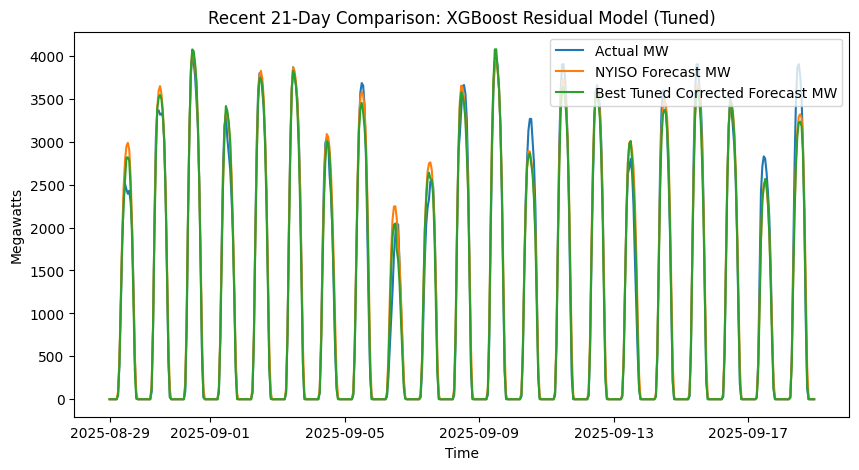

In [38]:
plt.figure(figsize=(10, 5))
plt.plot(recent_plot["time_local"], recent_plot["actual_mw"], label="Actual MW")
plt.plot(recent_plot["time_local"], recent_plot["forecast_mw"], label="NYISO Forecast MW")
plt.plot(recent_plot["time_local"], recent_plot["corrected_forecast_mw"], label="Best Tuned Corrected Forecast MW")
plt.title(f"Recent 21-Day Comparison: {best_model_name}")
plt.xlabel("Time")
plt.ylabel("Megawatts")
plt.legend()
plt.show()

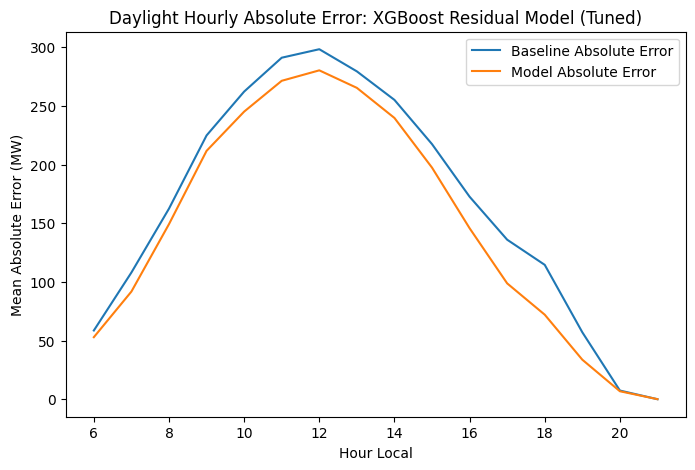

In [39]:
plt.figure(figsize=(8, 5))
plt.plot(hourly_day["hour_local"], hourly_day["baseline_abs_error_mw"], label="Baseline Absolute Error")
plt.plot(hourly_day["hour_local"], hourly_day["model_abs_error_mw"], label="Model Absolute Error")
plt.title(f"Daylight Hourly Absolute Error: {best_model_name}")
plt.xlabel("Hour Local")
plt.ylabel("Mean Absolute Error (MW)")
plt.legend()
plt.show()

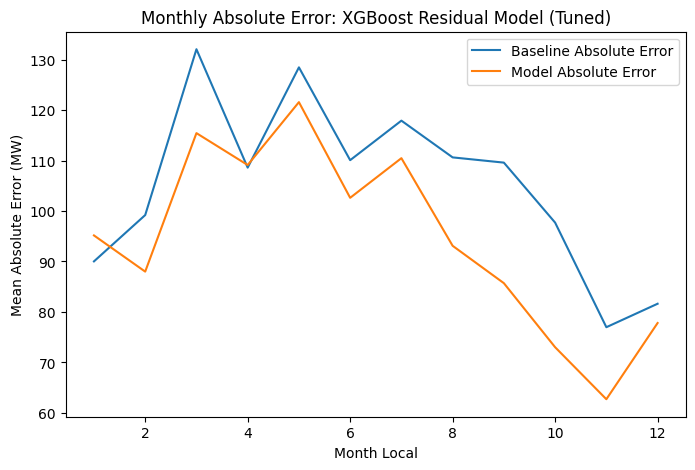

In [40]:
plt.figure(figsize=(8, 5))
plt.plot(monthly_all["month_local"], monthly_all["baseline_abs_error_mw"], label="Baseline Absolute Error")
plt.plot(monthly_all["month_local"], monthly_all["model_abs_error_mw"], label="Model Absolute Error")
plt.title(f"Monthly Absolute Error: {best_model_name}")
plt.xlabel("Month Local")
plt.ylabel("Mean Absolute Error (MW)")
plt.legend()
plt.show()

## Conclusion and Next Steps
x